# Notebook 03 — Modélisation avancée

Suite du notebook 02 (optionnel dans le PDF : livrable « amélioration »). Le 02 a montré que le gradient boosting fait *moins bien* que la régression logistique sur ce petit dataset : on concentre donc l'amélioration sur la **logreg retenue** (`class_weight="balanced"`, PR-AUC 0.644 en validation). Trois pistes :

1. **Tuning de l'hyperparamètre `C`** (validation croisée sur le train), avec comparaison avant/après
2. **Calibration des probabilités** (piste notée en conclusion du 02)
3. **Importance des features** (comprendre ce que le modèle utilise)

Notebook autonome (comme le 02) : tout le code nécessaire est redéfini ici. Mêmes constantes et même `RANDOM_STATE` que le 02, donc exactement les mêmes splits — les scores sont directement comparables.

Règle inchangée : tous les choix se font sur train (CV) + validation. Le test n'est touché qu'une fois, tout en bas.

In [1]:
# Verification du kernel (doit pointer vers .venv du projet)
import sys
print(sys.executable)

/usr/bin/python3


## 1. Chargement, split et fonctions (socle repris du notebook 02)

Rien de nouveau dans cette section : chargement, split 72/10/18, pipeline de préparation et métriques sont repris tels quels du notebook 02, pour que ce notebook se lise et s'exécute seul. La baseline est ré-entraînée en fin de section : c'est le « avant » de toutes les comparaisons.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted")

url = "./../data/raw/Credit_card_default.csv"
df = pd.read_csv(url)
# Leak : drop immediat de la colonne interdite
df = df.drop(columns=["predicted_default_payment_next_month"])

# Constantes (protocole notebook 01, section 6.1)
TARGET = "default_payment_next_month"
ID_COL = "id"
CAT_COLS = ["sex", "education_level", "marital_status"]
TEST_SIZE = 0.18
VAL_SIZE = 0.10
RANDOM_STATE = 42
K_TOP = 0.20  # budget de relance : 20% des clients (notebook 02, section 6)

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Coupe 1 : test mis de cote (touche une seule fois, a la fin)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
# Coupe 2 : 0.10 du total = 0.10 / 0.82 du restant
val_ratio = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=val_ratio, stratify=y_tmp, random_state=RANDOM_STATE
)
print(f"train {X_train.shape} | val {X_val.shape} | test {X_test.shape}")

train (2134, 24) | val (297, 24) | test (534, 24)


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


def recode_categories(X):
    """Regroupe les codes hors documentation en 'autres' (mapping fixe)."""
    X = X.copy()
    # education_level : 1=etudes sup, 2=universite, 3=lycee, 4=autres ; 0/5/6 -> 4
    X["education_level"] = X["education_level"].replace({0: 4, 5: 4, 6: 4})
    # marital_status : 1=marie, 2=celibataire, 3=autres ; 0 -> 3
    X["marital_status"] = X["marital_status"].replace({0: 3})
    return X


def make_pipeline(model, columns):
    """Pipeline complet : recodage + preparation + modele en dernier maillon."""
    num_cols = [c for c in columns if c not in CAT_COLS + [ID_COL]]
    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
            ("num", StandardScaler(), num_cols),
        ],
        remainder="drop",
    )
    return Pipeline([
        ("recode", FunctionTransformer(recode_categories)),
        ("prep", preprocess),
        ("clf", model),
    ])

In [3]:
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
)


def recall_at_topk(y_true, y_proba, k=0.20):
    """Part des vrais defauts captes en ciblant les k% clients les plus risques."""
    n_top = int(len(y_true) * k)
    ordre = np.argsort(y_proba)[::-1]          # indices tries par proba decroissante
    y_top = np.asarray(y_true)[ordre[:n_top]]  # vraies etiquettes du top k%
    return y_top.sum() / np.asarray(y_true).sum()


def evaluer(nom, y_true, y_proba, seuil=0.5, k=0.20):
    """Affiche les metriques cles d'un modele. Retourne la PR-AUC."""
    y_pred = (y_proba >= seuil).astype(int)
    pr_auc = average_precision_score(y_true, y_proba)
    print(f"--- {nom} ---")
    print(f"PR-AUC          : {pr_auc:.3f}  (aleatoire ~ {np.mean(y_true):.3f})")
    print(f"recall@top{int(k * 100):d}%    : {recall_at_topk(y_true, y_proba, k):.3f}")
    print(f"seuil {seuil:.3f} -> precision : {precision_score(y_true, y_pred):.3f}"
          f" | recall : {recall_score(y_true, y_pred):.3f}")
    print("matrice de confusion [[VN FP] [FN VP]] :")
    print(confusion_matrix(y_true, y_pred))
    return pr_auc

In [4]:
from sklearn.linear_model import LogisticRegression

# AVANT : la baseline du notebook 02 (C = 1, valeur par defaut)
baseline = make_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    X_train.columns,
)
baseline.fit(X_train, y_train)
proba_base = baseline.predict_proba(X_val)[:, 1]
_ = evaluer("AVANT : baseline notebook 02 (C=1)", y_val, proba_base, k=K_TOP)

--- AVANT : baseline notebook 02 (C=1) ---
PR-AUC          : 0.644  (aleatoire ~ 0.215)
recall@top20%    : 0.562
seuil 0.500 -> precision : 0.416 | recall : 0.734
matrice de confusion [[VN FP] [FN VP]] :
[[167  66]
 [ 17  47]]


## 2. Tuning de la logreg : l'hyperparamètre `C`

`C` est l'**inverse de la force de régularisation** : petit C = coefficients tirés vers 0 (modèle plus contraint, moins de sur-apprentissage), grand C = modèle plus libre. Défaut : C = 1 — c'est la baseline, notre « avant ».

Principe : `GridSearchCV` essaie chaque valeur de C en **validation croisée à 5 plis sur le train seul** — la validation reste vierge pour la comparaison finale. `scoring="average_precision"` = PR-AUC, notre métrique prioritaire.

Notation `clf__C` : dans un pipeline, on préfixe le paramètre par le nom du maillon (`clf`) et deux underscores.

In [5]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
valeurs_C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10]

grid = GridSearchCV(
    make_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
        X_train.columns,
    ),
    param_grid={"clf__C": valeurs_C},
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,  # pour visualiser le sur-apprentissage
)
grid.fit(X_train, y_train)

best_C = grid.best_params_["clf__C"]
print(f"meilleur C        : {best_C}")
print(f"PR-AUC CV (train) : {grid.best_score_:.3f}")

logreg_tunee = grid.best_estimator_
proba_tunee = logreg_tunee.predict_proba(X_val)[:, 1]
_ = evaluer(f"APRES : logreg tunee (C={best_C})", y_val, proba_tunee, k=K_TOP)

meilleur C        : 0.01
PR-AUC CV (train) : 0.544
--- APRES : logreg tunee (C=0.01) ---
PR-AUC          : 0.655  (aleatoire ~ 0.215)
recall@top20%    : 0.594
seuil 0.500 -> precision : 0.469 | recall : 0.703
matrice de confusion [[VN FP] [FN VP]] :
[[182  51]
 [ 19  45]]


### Courbe de tuning : PR-AUC en fonction de C

Lecture : chaque point = moyenne des 5 plis de CV. L'écart entre la courbe train et la courbe CV mesure le **sur-apprentissage** : plus C grandit (modèle libre), plus le modèle colle au train sans que la CV s'améliore. La ligne grise marque le « avant » (C=1), la verte le C retenu.

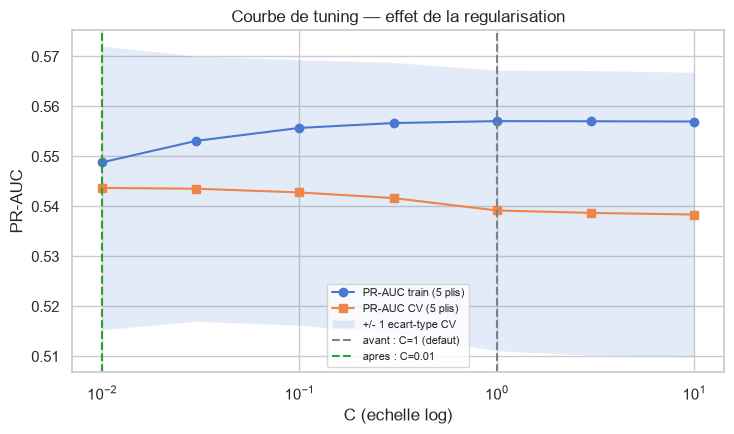

In [6]:
res = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(7.5, 4.5))
plt.plot(valeurs_C, res["mean_train_score"], marker="o", label="PR-AUC train (5 plis)")
plt.plot(valeurs_C, res["mean_test_score"], marker="s", label="PR-AUC CV (5 plis)")
plt.fill_between(valeurs_C,
                 res["mean_test_score"] - res["std_test_score"],
                 res["mean_test_score"] + res["std_test_score"],
                 alpha=0.15, label="+/- 1 ecart-type CV")
plt.axvline(1, ls="--", color="gray", label="avant : C=1 (defaut)")
plt.axvline(best_C, ls="--", color="tab:green", label=f"apres : C={best_C}")
plt.xscale("log")
plt.xlabel("C (echelle log)")
plt.ylabel("PR-AUC")
plt.title("Courbe de tuning — effet de la regularisation")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Comparaison avant / après (validation)

Trois vues de la même comparaison : les courbes précision-rappel (vision globale, tous seuils), les métriques côte à côte, et les matrices de confusion au seuil 0.5.

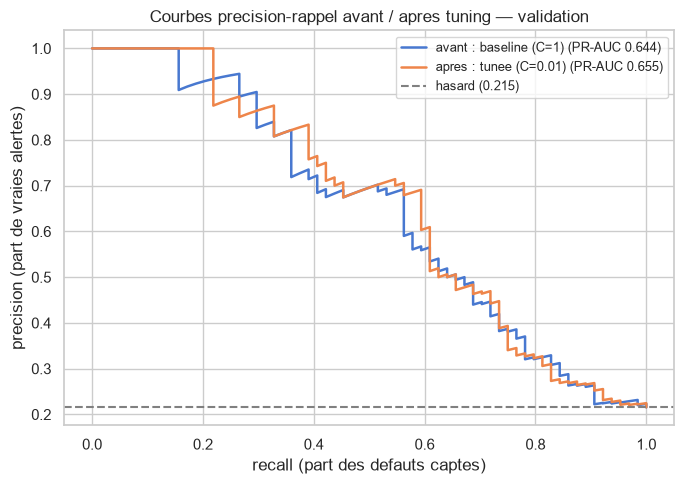

In [7]:
from sklearn.metrics import precision_recall_curve

comparaison = {
    "avant : baseline (C=1)": proba_base,
    f"apres : tunee (C={best_C})": proba_tunee,
}

plt.figure(figsize=(7, 5))
for label, proba in comparaison.items():
    prec, rec, _ = precision_recall_curve(y_val, proba)
    plt.plot(rec, prec, lw=1.8,
             label=f"{label} (PR-AUC {average_precision_score(y_val, proba):.3f})")
plt.axhline(y_val.mean(), ls="--", color="gray", label=f"hasard ({y_val.mean():.3f})")
plt.xlabel("recall (part des defauts captes)")
plt.ylabel("precision (part de vraies alertes)")
plt.title("Courbes precision-rappel avant / apres tuning — validation")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

                        pr_auc  precision  recall  f1_score  recall@top20%
modele                                                                    
avant : baseline (C=1)   0.644      0.416   0.734     0.531          0.562
apres : tunee (C=0.01)   0.655      0.469   0.703     0.562          0.594


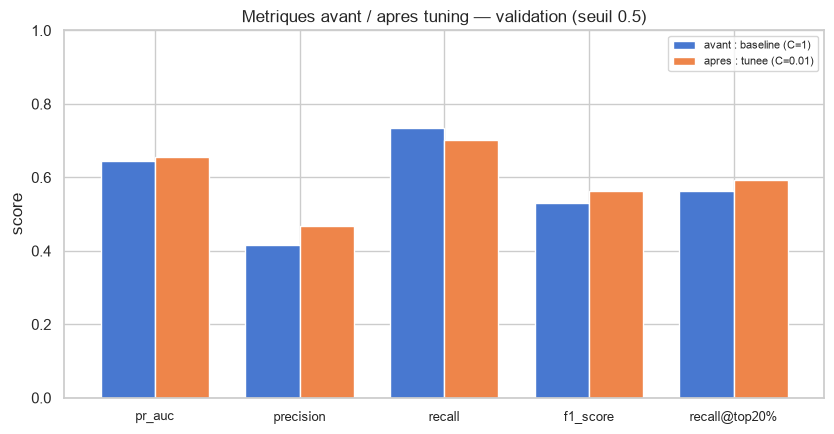

In [8]:
from sklearn.metrics import f1_score

lignes = []
for label, proba in comparaison.items():
    pred = (proba >= 0.5).astype(int)
    lignes.append({
        "modele": label,
        "pr_auc": average_precision_score(y_val, proba),
        "precision": precision_score(y_val, pred),
        "recall": recall_score(y_val, pred),
        "f1_score": f1_score(y_val, pred),
        "recall@top20%": recall_at_topk(y_val, proba, K_TOP),
    })
df_comp = pd.DataFrame(lignes).set_index("modele")
print(df_comp.round(3))

# Transpose : une famille de barres par metrique, avant vs apres cote a cote
df_comp.T.plot.bar(figsize=(8.5, 4.5), width=0.75)
plt.title("Metriques avant / apres tuning — validation (seuil 0.5)")
plt.ylabel("score")
plt.ylim(0, 1)
plt.xticks(rotation=0, fontsize=9)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

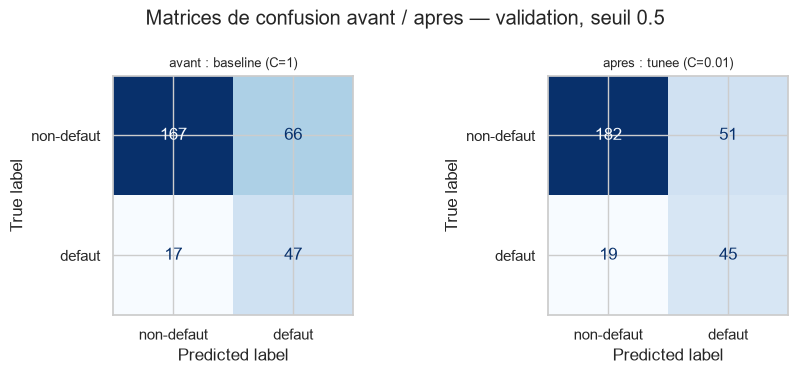

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, (label, proba) in zip(axes, comparaison.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_val, (proba >= 0.5).astype(int), ax=ax, colorbar=False, cmap="Blues",
        display_labels=["non-defaut", "defaut"],
    )
    ax.set_title(label, fontsize=9)
plt.suptitle("Matrices de confusion avant / apres — validation, seuil 0.5")
plt.tight_layout()
plt.show()

## 4. Calibration des probabilités

Un modèle est **calibré** si, parmi les clients auxquels il donne une proba de 0.6, environ 60% font réellement défaut. La calibration ne change (presque) pas le **classement** des clients — donc PR-AUC et recall@topK bougent peu — mais elle rend les probas **interprétables** par le métier (« ce client a 60% de risque »).

Point important pour nous : `class_weight="balanced"` **décale volontairement les probas vers le haut** (vu au notebook 02). Elles ne sont donc pas interprétables telles quelles. La calibration corrige ce décalage.

`CalibratedClassifierCV` ré-entraîne le modèle en CV interne sur le train et apprend une fonction de correction. Deux méthodes : `sigmoid` (Platt, paramétrique, robuste sur petits jeux) et `isotonic` (non paramétrique, plus flexible mais gourmande en données).

On mesure avec le **score de Brier** : moyenne des (proba - réalité)², plus petit = mieux.

In [10]:
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

variantes = {"avant : non calibre": logreg_tunee}
for methode in ["sigmoid", "isotonic"]:
    calib = CalibratedClassifierCV(clone(logreg_tunee), method=methode, cv=cv)
    calib.fit(X_train, y_train)
    variantes[f"apres : {methode}"] = calib

for nom, modele in variantes.items():
    proba = modele.predict_proba(X_val)[:, 1]
    print(f"{nom:20s} : Brier {brier_score_loss(y_val, proba):.4f}"
          f" | PR-AUC {average_precision_score(y_val, proba):.3f}"
          f" | proba moyenne {proba.mean():.3f} (taux reel {y_val.mean():.3f})")

avant : non calibre  : Brier 0.1889 | PR-AUC 0.655 | proba moyenne 0.449 (taux reel 0.215)
apres : sigmoid      : Brier 0.1274 | PR-AUC 0.650 | proba moyenne 0.211 (taux reel 0.215)
apres : isotonic     : Brier 0.1179 | PR-AUC 0.649 | proba moyenne 0.210 (taux reel 0.215)


### Courbe de calibration avant / après

Lecture : probas prédites en abscisse, fréquence réelle de défaut en ordonnée. Un modèle parfaitement calibré suit la diagonale. En dessous de la diagonale = probas trop hautes (sur-estimation du risque) — c'est exactement l'effet de `class_weight="balanced"` que la calibration corrige.

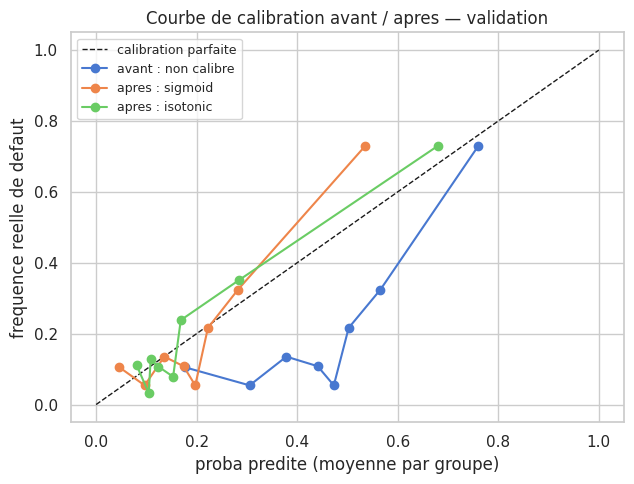

In [12]:
plt.figure(figsize=(6.5, 5))
plt.plot([0, 1], [0, 1], "k--", lw=1, label="calibration parfaite")
for nom, modele in variantes.items():
    proba = modele.predict_proba(X_val)[:, 1]
    freq_reelle, proba_moy = calibration_curve(y_val, proba, n_bins=8, strategy="quantile")
    plt.plot(proba_moy, freq_reelle, marker="o", label=nom)
plt.xlabel("proba predite (moyenne par groupe)")
plt.ylabel("frequence reelle de defaut")
plt.title("Courbe de calibration avant / apres — validation")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Importance des features

Deux angles complémentaires :

- **Coefficients de la logreg** : lisibles directement car les variables sont standardisées (même échelle). Signe = direction (positif = pousse vers le défaut), amplitude = force. Avec C=0.01, la régularisation « éteint » les features faibles (coefficients proches de 0).
- **Permutation importance** : on mélange une colonne au hasard et on mesure la chute de PR-AUC sur la validation ; grosse chute = feature importante. S'applique au pipeline entier, sur les colonnes **brutes**.

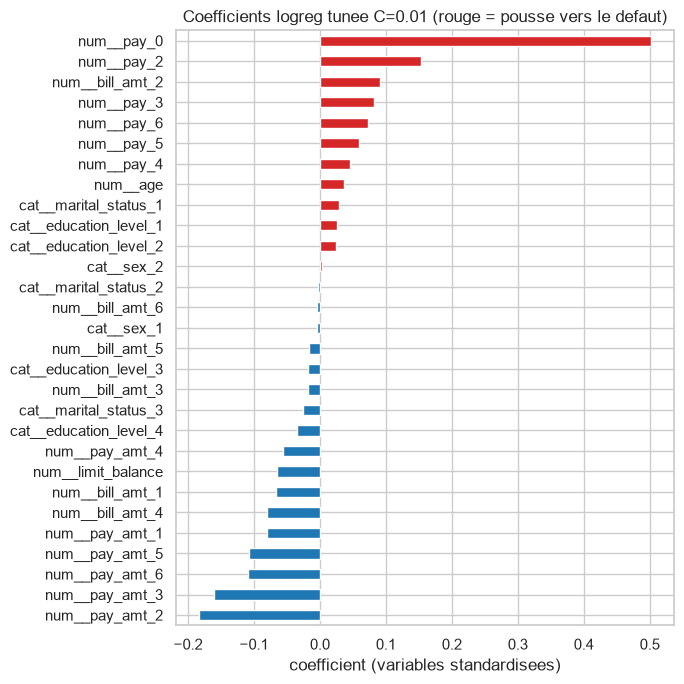

In [11]:
# Coefficients de la logreg tunee, sur les features transformees
noms = logreg_tunee.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(logreg_tunee.named_steps["clf"].coef_[0], index=noms).sort_values()

plt.figure(figsize=(7, 7))
coefs.plot.barh(color=np.where(coefs > 0, "tab:red", "tab:blue"))
plt.title(f"Coefficients logreg tunee C={best_C} (rouge = pousse vers le defaut)")
plt.xlabel("coefficient (variables standardisees)")
plt.tight_layout()
plt.show()

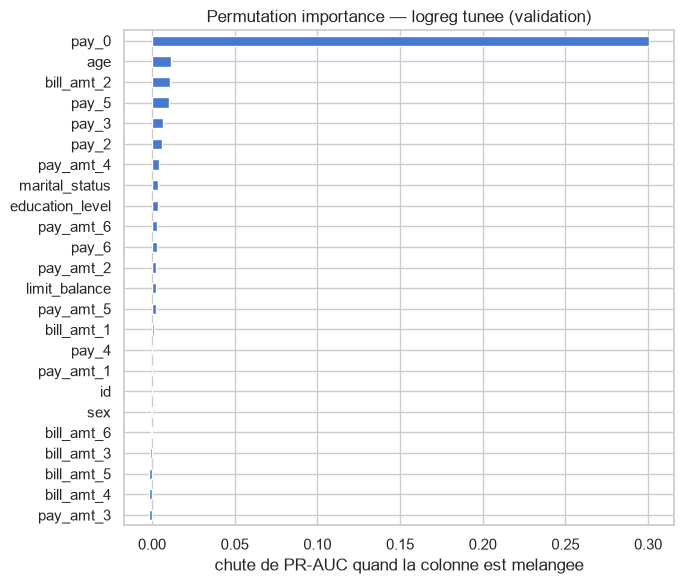

importance de id : 0.0000 (attendu ~0, la colonne est droppee)
top 5 features :
pay_0         0.3005
age           0.0114
bill_amt_2    0.0110
pay_5         0.0100
pay_3         0.0067
dtype: float64


In [12]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    logreg_tunee, X_val, y_val,
    scoring="average_precision", n_repeats=10, random_state=RANDOM_STATE,
)
imp = pd.Series(result.importances_mean, index=X_val.columns).sort_values()

plt.figure(figsize=(7, 6))
imp.plot.barh()
plt.title("Permutation importance — logreg tunee (validation)")
plt.xlabel("chute de PR-AUC quand la colonne est melangee")
plt.tight_layout()
plt.show()

# Sanity check : id est ecarte par le pipeline, son importance doit etre ~0
print(f"importance de id : {imp['id']:.4f} (attendu ~0, la colonne est droppee)")
print("top 5 features :")
print(imp.sort_values(ascending=False).head(5).round(4))

## 6. Choix final et évaluation sur le test

Baseline et logreg tunée ont la même complexité (même modèle, seul C change) : on garde simplement la meilleure PR-AUC validation. Pour la calibration : elle ne sert pas le tri top K%, on la note comme option si le métier veut lire les probas en absolu.

In [13]:
recap = pd.DataFrame({
    "pr_auc": {n: average_precision_score(y_val, p) for n, p in comparaison.items()},
    "recall@top20%": {n: recall_at_topk(y_val, p, K_TOP) for n, p in comparaison.items()},
}).sort_values("pr_auc", ascending=False)
print(recap.round(3))

retenu_nom = recap.index[0]
retenu = baseline if "baseline" in retenu_nom else logreg_tunee
print(f"\nModele retenu : {retenu_nom}")

                        pr_auc  recall@top20%
apres : tunee (C=0.01)   0.655          0.594
avant : baseline (C=1)   0.644          0.562

Modele retenu : apres : tunee (C=0.01)


In [14]:
# Evaluation finale sur le test (une seule fois)
proba_test = retenu.predict_proba(X_test)[:, 1]
seuil_topk = float(np.quantile(retenu.predict_proba(X_val)[:, 1], 1 - K_TOP))
_ = evaluer(f"FINAL sur test : {retenu_nom}", y_test, proba_test, seuil=seuil_topk, k=K_TOP)

--- FINAL sur test : apres : tunee (C=0.01) ---
PR-AUC          : 0.498  (aleatoire ~ 0.213)
recall@top20%    : 0.456
seuil 0.537 -> precision : 0.488 | recall : 0.518
matrice de confusion [[VN FP] [FN VP]] :
[[358  62]
 [ 55  59]]


### Conclusion

**Tuning.** Une régularisation plus forte que le défaut (C=0.01 au lieu de 1) améliore tout
en validation : PR-AUC 0.644 -> 0.655, recall@top20% 0.562 -> 0.594, et la courbe de tuning
montre un écart train/CV réduit (moins de sur-apprentissage). Sur le test : PR-AUC 0.498
(vs 0.488 pour la baseline au notebook 02), recall@top20% 0.456 (vs 0.465). Le gain reste
donc modeste et **ne se confirme pas nettement sur le test** — attendu avec un dataset aussi petit.
Le gradient boosting n'a pas été retravaillé : le notebook 02 l'a montré en retrait de la logreg.

**Calibration.** Le résultat le plus utile du notebook : `class_weight="balanced"` sur-estime
fortement le risque (proba moyenne 0.449 pour un taux réel de 0.215). La calibration
sigmoid/isotonic ramène la moyenne à ~0.21 et le Brier de 0.189 à ~0.12, sans toucher au
classement (PR-AUC quasi stable). À activer (via `CalibratedClassifierCV`) le jour où le métier
veut lire les probas en absolu ; inutile pour le tri top K%.

**Importance.** `pay_0` (statut de paiement le plus récent) domine tout : à lui seul 0.30 de
chute de PR-AUC quand on le mélange, contre ~0.01 pour les suivantes (age, bill_amt_2, pay_5).
Logique métier : le retard de paiement du mois dernier est le meilleur prédicteur du défaut du
mois prochain. Sanity check : l'importance de `id` est bien nulle.

**Limite de protocole.** Le test a maintenant servi deux fois (02 puis 03). C'est acceptable
documenté, mais on ne re-touchera plus au test.

**Action.** Reporter le choix dans `src/train.py` (`C=0.01`, une ligne), regénérer le modèle
et le fichier de scoring, mettre à jour `reports/model_report.md`, puis commit « modele avance ».